### Problem Statement

Airline Ticket Pricing is highly dynamic and influenced by multiple factors such as airline, route, travel class, departure and arrival time, and booking window. 

The objective of this project is to analyze Flight Booking Data to identify key drivers of ticket pricing and uncover meaningful patterns using Exploratory Data Analysis (EDA).

**Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

**Loading Dataset**

In [2]:
df = pd.read_csv("Airline_Flight_Dataset.csv")

**Exploring and Cleaning Data**

In [3]:
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [4]:
df.shape

(300153, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


In [6]:
df.isnull().sum()

index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop(columns = 'index', inplace = True)

In [9]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [10]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [11]:
df['airline'].nunique()

6

In [12]:
df['airline'].unique()

<StringArray>
['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
Length: 6, dtype: str

In [13]:
df['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

**Exploratory Data Analysis (EDA)**

**1) Airline Frequency**

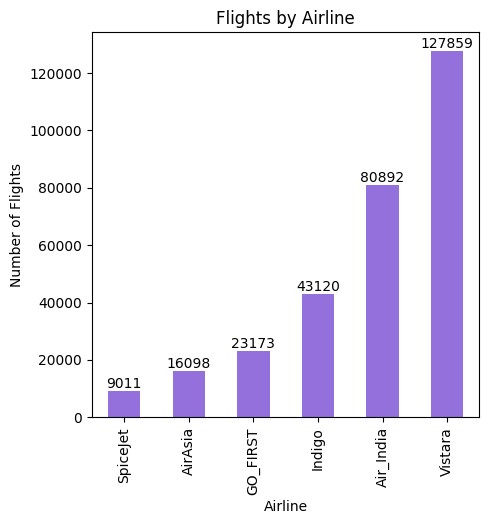

In [14]:
plt.figure(figsize=(5,5))
ax = df['airline'].value_counts(ascending=True).plot(kind='bar', color='#9370DB')
for i in ax.containers:
    ax.bar_label(i) 
plt.xlabel('Airline')
plt.ylabel('Number of Flights')
plt.title('Flights by Airline')
plt.show()

**Insight:**

Vistara operates the highest number of flights (127,859), indicating a strong presence in the dataset.  
SpiceJet has the lowest number of flights (9,011), suggesting comparatively lower flight frequency. 

**2) Departure & Arrival Time**

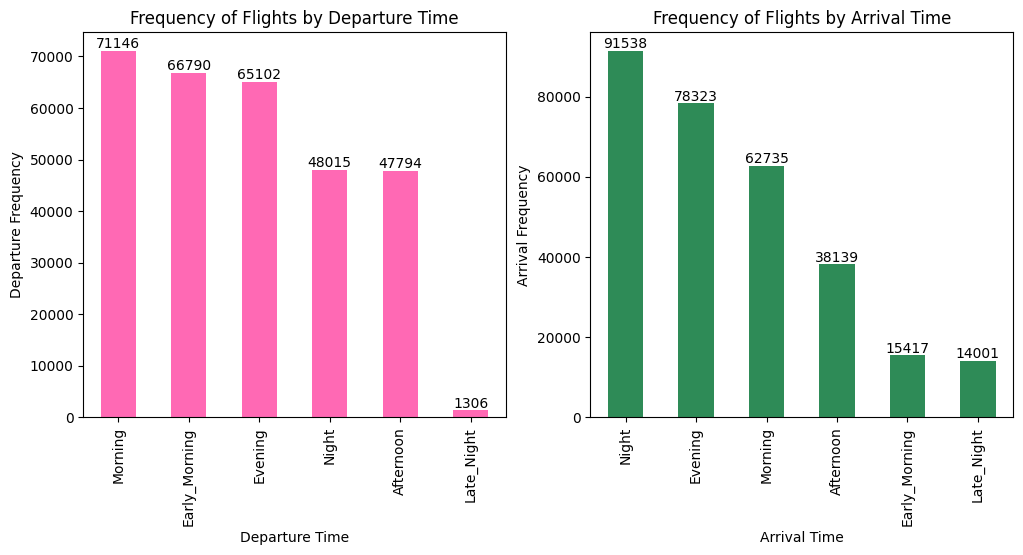

In [33]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
ax = df['departure_time'].value_counts().plot(kind='bar', color='#FF69B4')
for i in ax.containers:
    ax.bar_label(i) 
plt.xlabel('Departure Time')
plt.ylabel('Departure Frequency')
plt.title('Frequency of Flights by Departure Time')

plt.subplot(1,2,2)
ax = df['arrival_time'].value_counts().plot(kind='bar', color='#2E8B57')
for i in ax.containers:
    ax.bar_label(i) 
plt.xlabel('Arrival Time')
plt.ylabel('Arrival Frequency')
plt.title('Frequency of Flights by Arrival Time')

plt.show()

**Insight:**

The maximum number of flights depart in the Morning (71,146), while the minimum number of flights depart during Late Night (1,306).

In terms of arrivals, the highest number of flights arrive at Night (91,538), whereas the lowest number of flights arrive during Late Night (14,001).

**3) Source & Destination Cities**

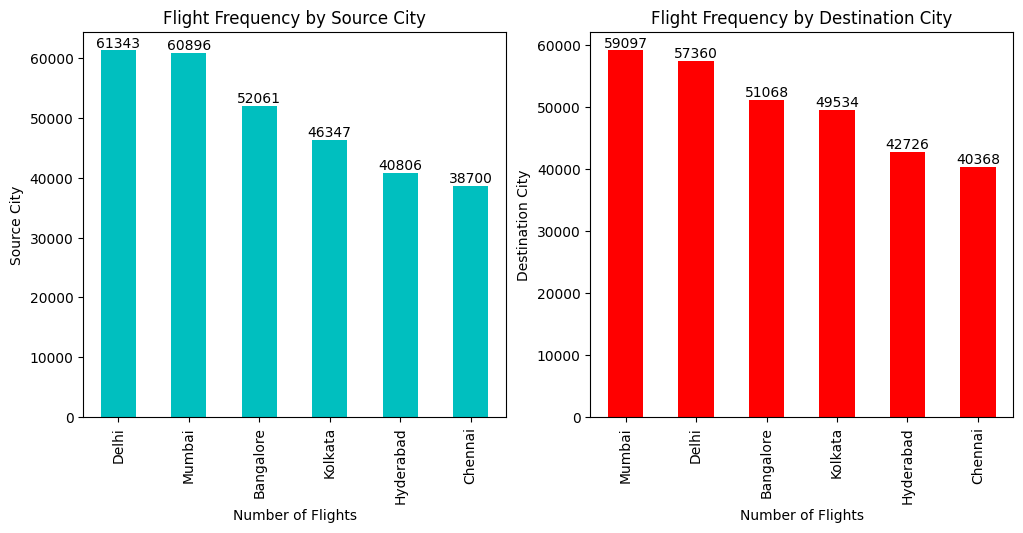

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
ax = df['source_city'].value_counts().plot(kind='bar',color='c')
for i in ax.containers:
    ax.bar_label(i) 
plt.xlabel('Number of Flights')
plt.ylabel('Source City')
plt.title('Flight Frequency by Source City')

plt.subplot(1,2,2)
ax = df['destination_city'].value_counts().plot(kind='bar',color='r')
for i in ax.containers:
    ax.bar_label(i) 
plt.xlabel('Number of Flights')
plt.ylabel('Destination City')
plt.title('Flight Frequency by Destination City')

plt.show()

**Insight:**

The majority of flights originate from Delhi (61,343), making it the busiest source city in the dataset. Chennai has the lowest number of departures (38,700).

For destinations, Mumbai receives the highest number of flights (59,097), while Chennai records the lowest number of arrivals (40,368).

In [17]:
df.groupby('airline')['price'].mean()

airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64

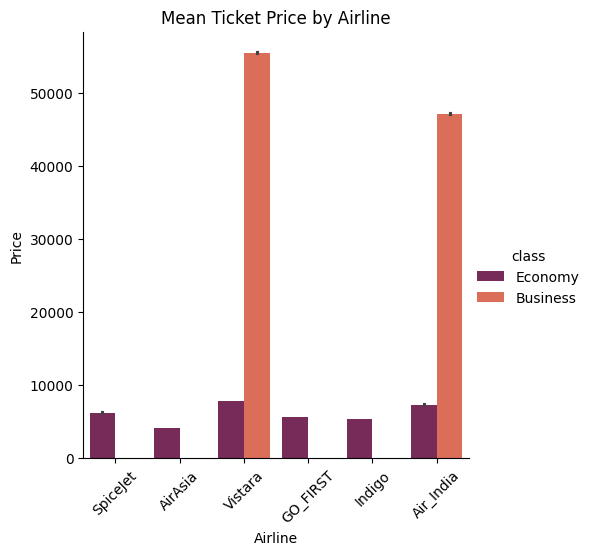

In [18]:
sns.catplot(x='airline', y='price', data=df, kind='bar', palette='rocket', hue='class')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.title('Mean Ticket Price by Airline')
plt.xticks(rotation=45)
plt.show()

**Insight:**
  
Only Vistara and Air India offer Business class flights in the dataset.  
Among them, Vistara has the highest average ticket price in Business class, while AirAsia shows the lowest average ticket price overall, primarily in Economy class.

In [19]:
df.groupby('departure_time')['price'].mean()

departure_time
Afternoon        18179.203331
Early_Morning    20370.676718
Evening          21232.361894
Late_Night        9295.299387
Morning          21630.760254
Night            23062.146808
Name: price, dtype: float64

In [20]:
df.groupby('arrival_time')['price'].mean()

arrival_time
Afternoon        18494.598993
Early_Morning    14993.139521
Evening          23044.371615
Late_Night       11284.906078
Morning          22231.076098
Night            21586.758341
Name: price, dtype: float64

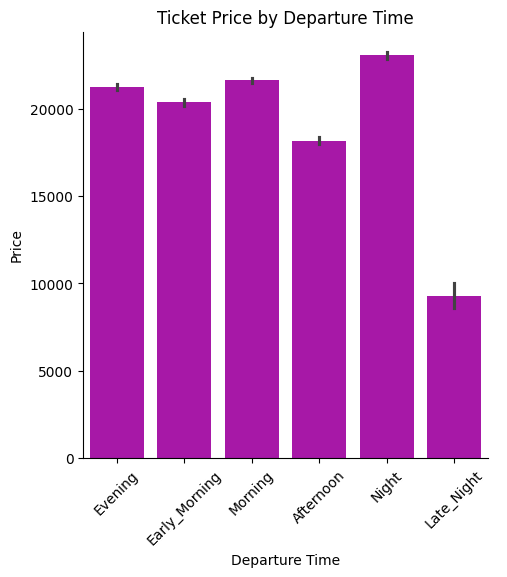

In [21]:
sns.catplot(x='departure_time', y='price', data=df, kind='bar', color='m')
plt.xlabel('Departure Time')
plt.ylabel('Price')
plt.title('Ticket Price by Departure Time')
plt.xticks(rotation=45)
plt.show()

**Insight:**

Flights departing during Late Night have the lowest average ticket prices.  
For other departure time slots, the price difference is relatively small.

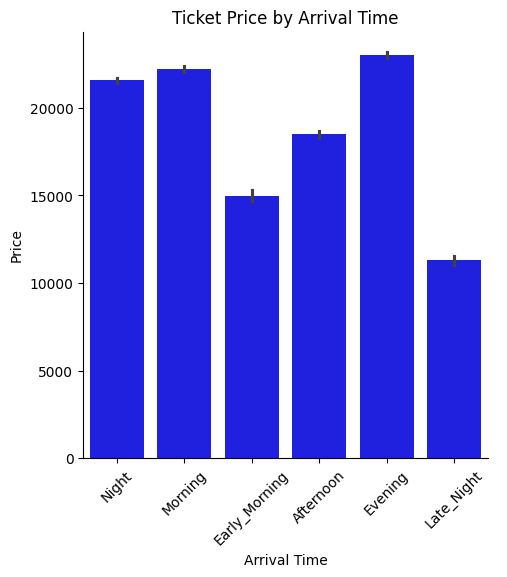

In [22]:
sns.catplot(x='arrival_time', y='price', data=df, kind='bar', color='b')
plt.xlabel('Arrival Time')
plt.ylabel('Price')
plt.title('Ticket Price by Arrival Time')
plt.xticks(rotation=45)
plt.show()

**Insight:** 

Flights arriving during Late Night tend to have the lowest average prices, while other arrival time categories show similar pricing patterns.

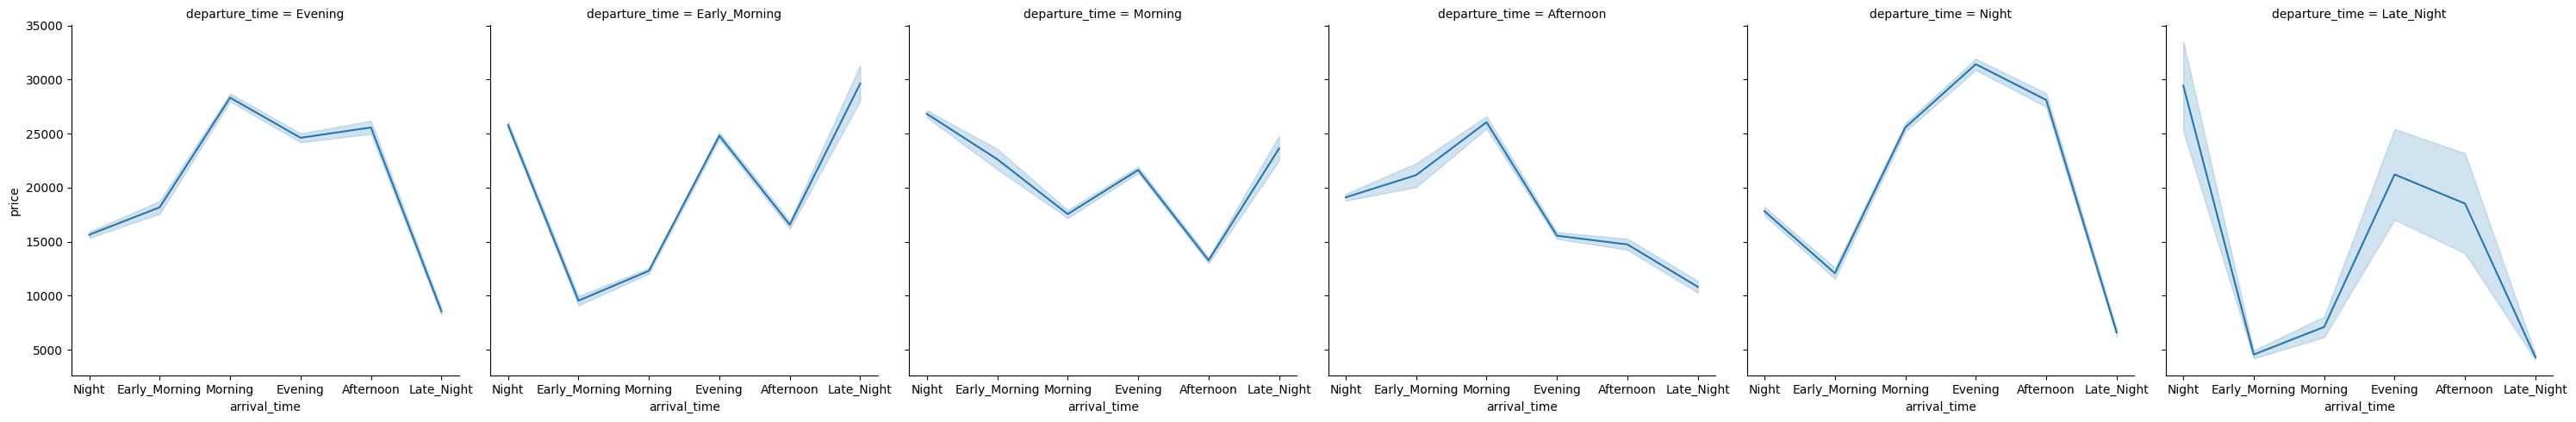

In [23]:
sns.relplot(x='arrival_time', y='price', data=df, col='departure_time', kind='line')
plt.show()

In [24]:
df.groupby('source_city')['price'].mean()

source_city
Bangalore    21469.460575
Chennai      21995.339871
Delhi        18951.326639
Hyderabad    20155.623879
Kolkata      21746.235679
Mumbai       21483.818839
Name: price, dtype: float64

In [25]:
df.groupby('destination_city')['price'].mean()

destination_city
Bangalore    21593.955784
Chennai      21953.323969
Delhi        18436.767870
Hyderabad    20427.661284
Kolkata      21959.557556
Mumbai       21372.529469
Name: price, dtype: float64

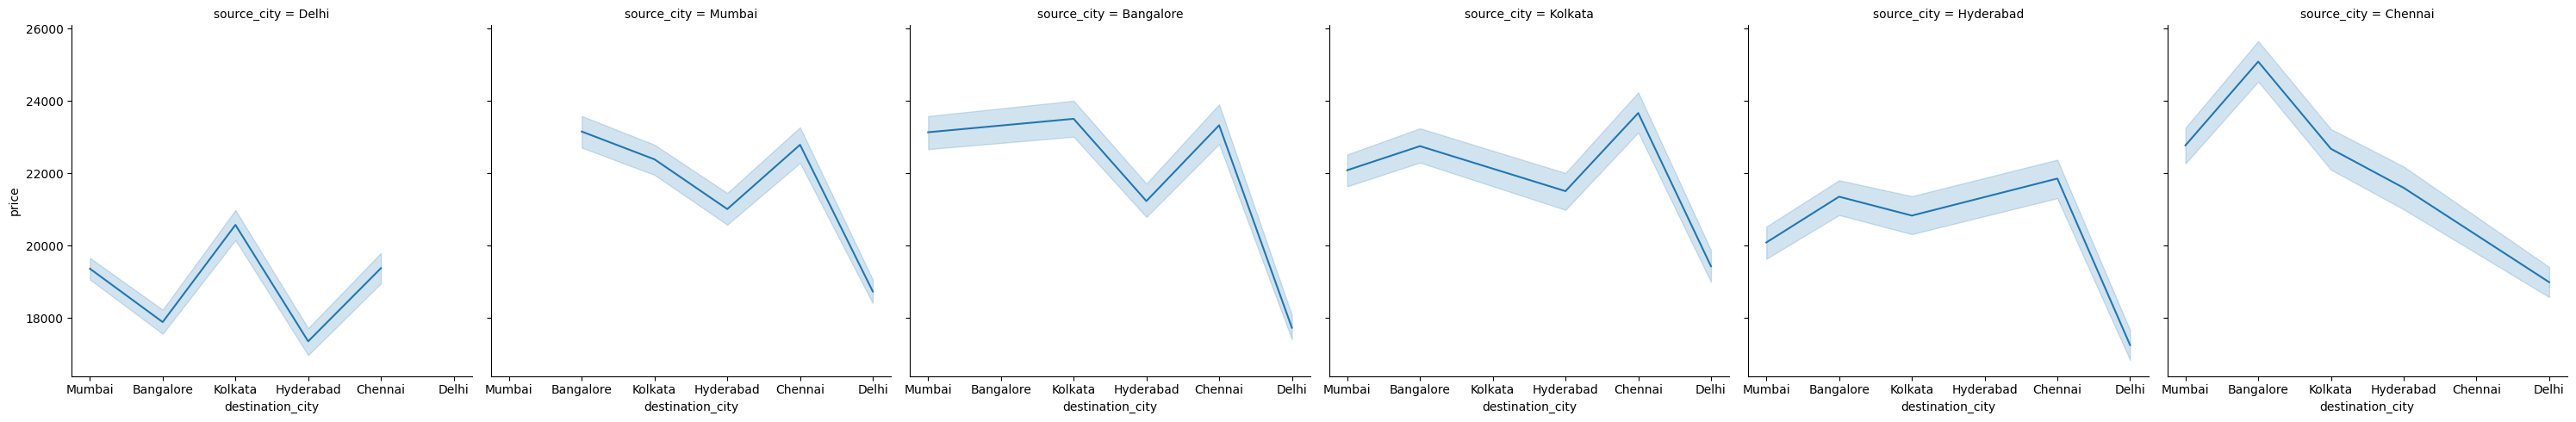

In [26]:
sns.relplot(x='destination_city', y='price', data=df, col='source_city', kind='line')
plt.show()

In [27]:
df['days_left'].nunique()

49

In [28]:
df['days_left'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [29]:
df.groupby('days_left')['price'].mean()

days_left
1     21591.867151
2     30211.299801
3     28976.083569
4     25730.905653
5     26679.773368
6     24856.493902
7     25588.367351
8     24895.883995
9     25726.246072
10    25572.819134
11    22990.656070
12    22505.803322
13    22498.885384
14    22678.002363
15    21952.540852
16    20503.546237
17    20386.353949
18    19987.445168
19    19507.677375
20    19699.983390
21    19430.494058
22    19590.667385
23    19840.913451
24    19803.908896
25    19571.641791
26    19238.290278
27    19950.866195
28    19534.986047
29    19744.653119
30    19567.580834
31    19392.706612
32    19258.135308
33    19306.271739
34    19562.008266
35    19255.652996
36    19517.688444
37    19506.306516
38    19734.912316
39    19262.095556
40    19144.972439
41    19347.440460
42    19154.261659
43    19340.528894
44    19049.080174
45    19199.876307
46    19305.351623
47    18553.272038
48    18998.126851
49    18992.971888
Name: price, dtype: float64

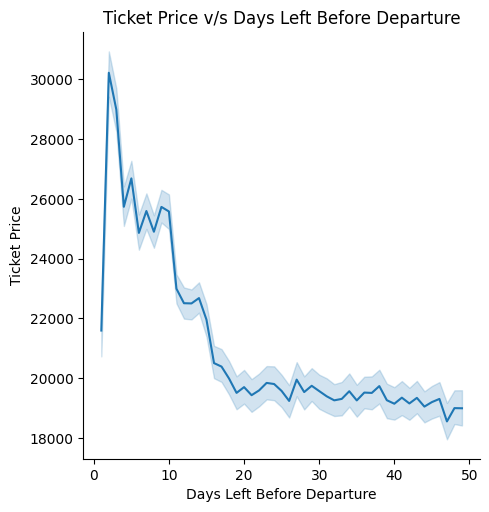

In [34]:
sns.relplot(x='days_left', y='price', data=df, kind='line')
plt.title("Ticket Price v/s Days Left Before Departure")
plt.xlabel("Days Left Before Departure")
plt.ylabel("Ticket Price")
plt.show()

**Insight:**
  
Ticket prices generally increase as the departure date approaches.  
However, when only one day is left before departure, prices do not rise significantly, possibly due to airlines offering last-minute discounts to fill remaining seats.

In [31]:
df['class'].unique()

<StringArray>
['Economy', 'Business']
Length: 2, dtype: str

In [32]:
df.groupby('class')['price'].mean()

class
Business    52540.081124
Economy      6572.342383
Name: price, dtype: float64